In [19]:
import pandas as pd

data = pd.read_csv("inventory_data_clean.csv")
print(data.head())

   product_id product_name  stock_level  daily_sales  lead_time_days
0         101         rice          500           25               7
1         102      noodles          300           20               5
2         103        sauce          200            8              10
3         104        sugar          150            6              12
4         105       coffee          100            5               8


In [20]:
data["inventory_turnover_days"] = data["stock_level"] / data["daily_sales"]

In [21]:
# Reorder Point
data["reorder_point"] = data["daily_sales"] * data["lead_time_days"]

# Need reorder
data["need_reorder"] = data["stock_level"] <= data["reorder_point"]

# Xem kết quả
data[["product_name","stock_level","reorder_point","need_reorder"]]

,product_name,stock_level,reorder_point,need_reorder
0,rice,500,175,False
1,noodles,300,100,False
2,sauce,200,80,False
3,sugar,150,72,False
4,coffee,100,40,False
5,tea,120,42,False
6,milk,400,150,False
7,bread,350,112,False
8,butter,180,90,False
9,cheese,200,84,False


In [22]:
urgent = data[data["need_reorder"] == True]

urgent[["product_name","stock_level","reorder_point"]]

,product_name,stock_level,reorder_point


In [23]:
# sort theo turnover
fast_selling = data.sort_values(by="inventory_turnover_days")

fast_selling[["product_name","inventory_turnover_days"]]

,product_name,inventory_turnover_days
7,bread,12.500000
6,milk,13.333333
1,noodles,15.000000
9,cheese,16.666667
5,tea,17.142857
0,rice,20.000000
4,coffee,20.000000
8,butter,20.000000
2,sauce,25.000000
3,sugar,25.000000


In [24]:
top_fast = data.nsmallest(3, "inventory_turnover_days")

top_fast[["product_name","inventory_turnover_days"]]

,product_name,inventory_turnover_days
7,bread,12.500000
6,milk,13.333333
1,noodles,15.000000


In [25]:
top_slow = data.nlargest(3, "inventory_turnover_days")

top_slow[["product_name","inventory_turnover_days"]]

,product_name,inventory_turnover_days
2,sauce,25.0
3,sugar,25.0
0,rice,20.0


In [26]:
total_stock = data["stock_level"].sum()

print("Total stock:", total_stock)

Total stock: 2500


In [27]:
avg_turnover = data["inventory_turnover_days"].mean()

print("Average turnover days:", avg_turnover)

Average turnover days: 18.464285714285715


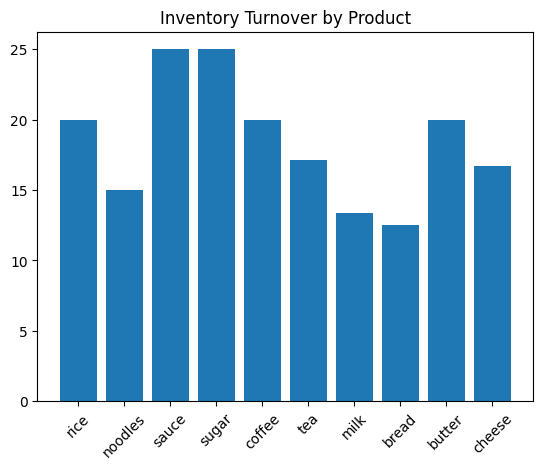

In [28]:
import matplotlib.pyplot as plt

plt.bar(data["product_name"], data["inventory_turnover_days"])
plt.xticks(rotation=45)
plt.title("Inventory Turnover by Product")
plt.show()